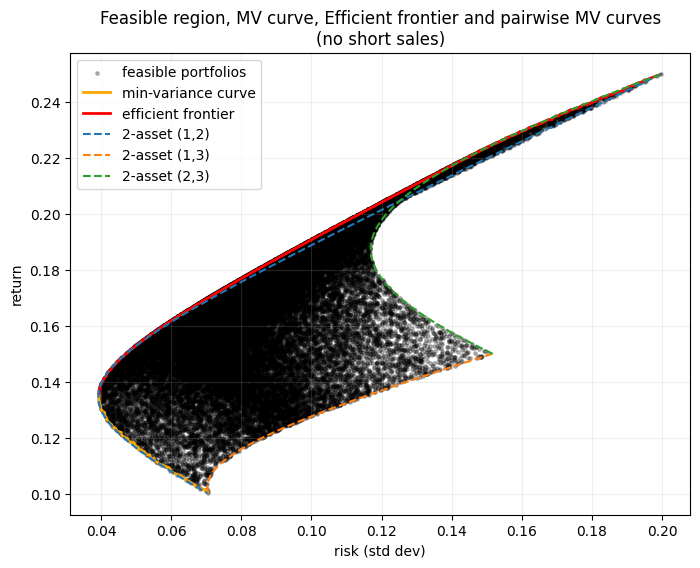

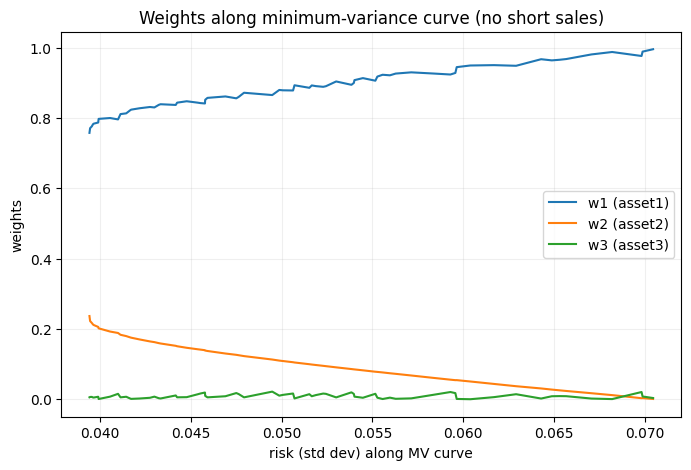

Minimize w^T C w subject to w1+w2+w3 = 1 and w_i >= 0 for i=1..3
We approximated the MV curve numerically by random sampling and taking the lower envelope.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

mu = np.array([0.1, 0.25, 0.15])
C = np.array([
    [0.005, -0.01, 0.004],
    [-0.01, 0.04, -0.002],
    [0.004, -0.002, 0.023]
])

n_port = 50000

R = []     # returns
S = []     # risks (std dev)
W = []     # weights

for _ in range(n_port):
    w = np.random.rand(3)     # non-negative
    w = w / (w[0] + w[1] + w[2])   # normalize

    r = 0.0
    for j in range(3):
        r += w[j] * mu[j]

    v = 0.0
    for a in range(3):
        for b in range(3):
            v += w[a] * C[a][b] * w[b]

    sd = np.sqrt(v)

    R.append(r)
    S.append(sd)
    W.append(w)

R = np.array(R)
S = np.array(S)
W = np.array(W)

plt.figure(figsize=(8,6))
plt.scatter(S, R, s=6, alpha=0.25, label="feasible portfolios",color='black')

idx_by_r = np.argsort(R)
mv_idx = []
min_sd = 1e9
tol = 1e-12

for idx in idx_by_r:
    if S[idx] < min_sd - tol:
        mv_idx.append(idx)
        min_sd = S[idx]

mv_idx = np.array(mv_idx)
mv_sd = S[mv_idx]
mv_r  = R[mv_idx]

order = np.argsort(mv_r)
plt.plot(mv_sd[order], mv_r[order], color='orange', linewidth=2, label="min-variance curve")

idx_by_s = np.argsort(S)
ef_idx = []
max_r = -1e9

for idx in idx_by_s:
    if R[idx] > max_r + tol:
        ef_idx.append(idx)
        max_r = R[idx]

ef_idx = np.array(ef_idx)
ef_sd = S[ef_idx]
ef_r  = R[ef_idx]

plt.plot(ef_sd, ef_r, color='red', linewidth=2, label="efficient frontier")

def two_asset_curve(i,j,steps=201):
    xs = []
    ys = []
    for a in np.linspace(0,1,steps):
        w = np.zeros(3)
        w[i] = a
        w[j] = 1.0 - a
        r = w[0]*mu[0] + w[1]*mu[1] + w[2]*mu[2]
        v = 0.0
        for p in range(3):
            for q in range(3):
                v += w[p]*C[p][q]*w[q]
        sd = np.sqrt(v)
        xs.append(sd); ys.append(r)
    return np.array(xs), np.array(ys)

x12,y12 = two_asset_curve(0,1)
x13,y13 = two_asset_curve(0,2)
x23,y23 = two_asset_curve(1,2)

plt.plot(x12, y12, '--', label='2-asset (1,2)')
plt.plot(x13, y13, '--', label='2-asset (1,3)')
plt.plot(x23, y23, '--', label='2-asset (2,3)')

plt.xlabel("risk (std dev)")
plt.ylabel("return")
plt.title("Feasible region, MV curve, Efficient frontier and pairwise MV curves\n(no short sales)")
plt.legend()
plt.grid(alpha=0.2)
plt.show()

mv_order = mv_idx[np.argsort(mv_r)]
mv_sd_order = S[mv_order]
w1 = [W[k][0] for k in mv_order]
w2 = [W[k][1] for k in mv_order]
w3 = [W[k][2] for k in mv_order]

plt.figure(figsize=(8,5))
plt.plot(mv_sd_order, w1, label='w1 (asset1)')
plt.plot(mv_sd_order, w2, label='w2 (asset2)')
plt.plot(mv_sd_order, w3, label='w3 (asset3)')
plt.xlabel("risk (std dev) along MV curve")
plt.ylabel("weights")
plt.title("Weights along minimum-variance curve (no short sales)")
plt.legend()
plt.grid(alpha=0.2)
plt.show()

print("Minimize w^T C w subject to w1+w2+w3 = 1 and w_i >= 0 for i=1..3")
print("We approximated the MV curve numerically by random sampling and taking the lower envelope.")


In [ ]:
import yfinance as yf
import pandas as pd
import time

def build_dataset(index_ticker, inside, outside, outname,
                  start="2021-01-01", end="2025-12-31", pause=1.5):

    tickers = [index_ticker] + inside + outside
    print("\nwill download", len(tickers), "tickers for", outname)

    master = None

    for t in tickers:
        print("downloading", t)

        try:
            df = yf.download(t, start=start, end=end,
                             progress=False, auto_adjust=True)
        except:
            print("  failed:", t)
            time.sleep(pause)
            continue

        if df is None or len(df) == 0:
            print("  empty:", t)
            time.sleep(pause)
            continue

        close = pd.DataFrame(df["Close"])
        close.columns = [t]

        if master is None:
            master = close
        else:
            master = master.join(close, how="inner")

        time.sleep(pause)

    if master is None:
        print("no data collected")
        return

    master.reset_index(inplace=True)
    master.rename(columns={"index":"Date"}, inplace=True)

    master.to_csv(outname, index=False)

    print("\n", outname, "created")
    print("rows:", master.shape[0])
    print("cols:", master.shape[1])
    print(master.head())



nse_index = "^NSEI"

nse_inside = [
    "RELIANCE.NS","TCS.NS","INFY.NS","HDFCBANK.NS","ICICIBANK.NS",
    "LT.NS","ITC.NS","SBIN.NS","BHARTIARTL.NS","HINDUNILVR.NS"
]

nse_outside = [
    "IDEA.NS","YESBANK.NS","SUZLON.NS","PNB.NS","IRFC.NS",
    "FEDERALBNK.NS","BHEL.NS","SAIL.NS","IDFCFIRSTB.NS","UCOBANK.NS"
]

build_dataset(nse_index, nse_inside, nse_outside, "nsedata1.csv")



bse_index = "^BSESN"

bse_inside = [
    "RELIANCE.BO","TCS.BO","INFY.BO","HDFCBANK.BO","ICICIBANK.BO",
    "LT.BO","ITC.BO","SBIN.BO","BHARTIARTL.BO","HINDUNILVR.BO"
]

bse_outside = [
    "IDEA.BO","YESBANK.BO","SUZLON.BO","PNB.BO","IRFC.BO",
    "FEDERALBNK.BO","BHEL.BO","SAIL.BO","IDFCFIRSTB.BO","UCOBANK.BO"
]

build_dataset(bse_index, bse_inside, bse_outside, "bsedata1.csv")



will download 21 tickers for nsedata1.csv
downloading ^NSEI
downloading RELIANCE.NS
downloading TCS.NS
downloading INFY.NS
downloading HDFCBANK.NS
downloading ICICIBANK.NS
downloading LT.NS
downloading ITC.NS
downloading SBIN.NS
downloading BHARTIARTL.NS
downloading HINDUNILVR.NS
downloading IDEA.NS
downloading YESBANK.NS
downloading SUZLON.NS
downloading PNB.NS
downloading IRFC.NS
downloading FEDERALBNK.NS
downloading BHEL.NS
downloading SAIL.NS
downloading IDFCFIRSTB.NS
downloading UCOBANK.NS

 nsedata1.csv created
rows: 1216
cols: 22
        Date         ^NSEI  RELIANCE.NS       TCS.NS      INFY.NS  \
0 2021-01-29  13634.599609   835.197693  2735.116699  1090.760864   
1 2021-02-01  14281.200195   859.388245  2759.730469  1109.995972   
2 2021-02-02  14647.849609   873.217957  2816.078857  1119.107056   
3 2021-02-03  14789.950195   875.417114  2813.090088  1130.903320   
4 2021-02-04  14895.650391   872.537781  2802.893066  1126.237671   

   HDFCBANK.NS  ICICIBANK.NS        LT.NS



--- Processing file: nsedata1.csv ---

columns found: ['^NSEI', 'RELIANCE.NS', 'TCS.NS', 'INFY.NS', 'HDFCBANK.NS', 'ICICIBANK.NS', 'LT.NS', 'ITC.NS', 'SBIN.NS', 'BHARTIARTL.NS', 'HINDUNILVR.NS', 'IDEA.NS', 'YESBANK.NS', 'SUZLON.NS', 'PNB.NS', 'IRFC.NS', 'FEDERALBNK.NS', 'BHEL.NS', 'SAIL.NS', 'IDFCFIRSTB.NS', 'UCOBANK.NS']
using index column: ^NSEI
number of stock columns: 20


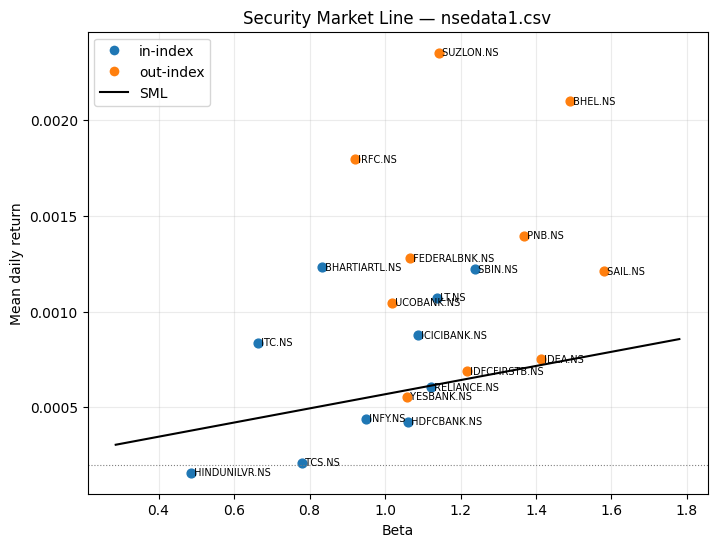


Stock        Beta      MeanRet    CAPM_ret    Diff (Actual - CAPM)
-----------------------------------------------------------------
RELIANCE.NS     1.122   0.000604   0.000613   -0.000009
TCS.NS          0.780   0.000211   0.000487   -0.000276
INFY.NS         0.950   0.000440   0.000549   -0.000109
HDFCBANK.NS     1.061   0.000425   0.000591   -0.000165
ICICIBANK.NS    1.089   0.000877   0.000601   0.000277
LT.NS           1.139   0.001073   0.000619   0.000454
ITC.NS          0.663   0.000838   0.000444   0.000394
SBIN.NS         1.238   0.001222   0.000656   0.000565
BHARTIARTL.NS    0.832   0.001232   0.000506   0.000726
HINDUNILVR.NS    0.487   0.000158   0.000378   -0.000220
IDEA.NS         1.412   0.000750   0.000721   0.000030
YESBANK.NS      1.058   0.000555   0.000590   -0.000034
SUZLON.NS       1.142   0.002352   0.000621   0.001732
PNB.NS          1.368   0.001396   0.000704   0.000692
IRFC.NS         0.920   0.001795   0.000538   0.001257
FEDERALBNK.NS    1.066   0.001278

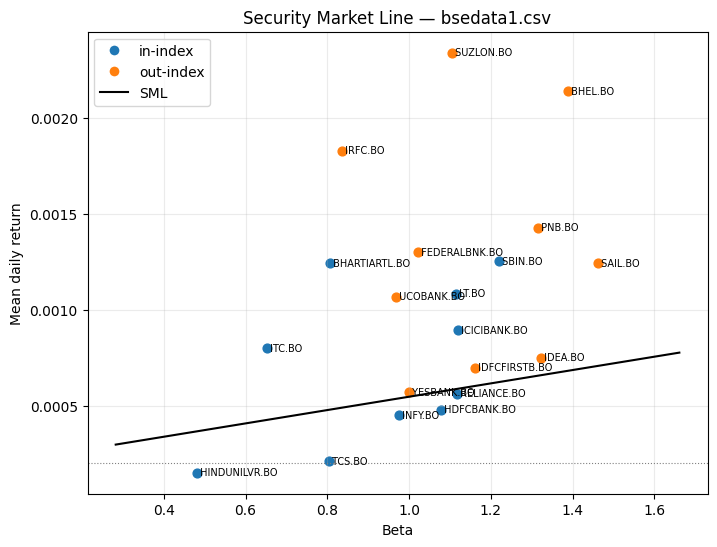


Stock        Beta      MeanRet    CAPM_ret    Diff (Actual - CAPM)
-----------------------------------------------------------------
RELIANCE.BO     1.116   0.000561   0.000587   -0.000026
TCS.BO          0.803   0.000209   0.000478   -0.000269
INFY.BO         0.975   0.000451   0.000537   -0.000087
HDFCBANK.BO     1.079   0.000478   0.000574   -0.000095
ICICIBANK.BO    1.120   0.000894   0.000588   0.000306
LT.BO           1.116   0.001085   0.000587   0.000498
ITC.BO          0.653   0.000800   0.000426   0.000375
SBIN.BO         1.220   0.001253   0.000623   0.000630
BHARTIARTL.BO    0.807   0.001242   0.000479   0.000762
HINDUNILVR.BO    0.482   0.000150   0.000366   -0.000216
IDEA.BO         1.322   0.000750   0.000658   0.000091
YESBANK.BO      0.999   0.000569   0.000546   0.000023
SUZLON.BO       1.106   0.002341   0.000583   0.001758
PNB.BO          1.316   0.001429   0.000656   0.000772
IRFC.BO         0.835   0.001830   0.000489   0.001341
FEDERALBNK.BO    1.022   0.001301 

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

files = ["nsedata1.csv", "bsedata1.csv"]

# annual -> daily rf (trading days ~252)
rf_daily = 0.05 / 252.0

for fname in files:

    print("\n\n--- Processing file:", fname, "---\n")

    df = pd.read_csv(fname, parse_dates=["Date"])
    df.set_index("Date", inplace=True)

    print("columns found:", list(df.columns))
   
    rets = df.pct_change().dropna(how="all")   # drop first NaN row
    rets = rets.dropna(how="any")

    idx_col = df.columns[0]
    stock_cols = list(df.columns[1:]) 

    print("using index column:", idx_col)
    print("number of stock columns:", len(stock_cols))

    mret = rets[idx_col]
    sret = rets[stock_cols]  

    mean_m = mret.mean()
    mean_s = sret.mean() 

    betas = []
    for col in stock_cols:
        cov = sret[col].cov(mret)          
        var = mret.var(ddof=1)   
        if var == 0:
            b = np.nan
        else:
            b = cov / var
        betas.append(b)
    betas = np.array(betas)

    capm_ret = rf_daily + betas * (mean_m - rf_daily)

    x_min = np.nanmin(betas) - 0.2
    x_max = np.nanmax(betas) + 0.2
    x = np.linspace(x_min, x_max, 200)
    y = rf_daily + x * (mean_m - rf_daily)

    plt.figure(figsize=(8,6))
    n = len(stock_cols)
    split = min(10, n//2 if n>=2 else n)
    colors = ['C0' if i < split else 'C1' for i in range(n)]

    for i, col in enumerate(stock_cols):
        plt.scatter(betas[i], mean_s[col], color=colors[i], s=40)
        plt.text(betas[i], mean_s[col], " " + col, fontsize=7, va='center')

    plt.plot(x, y, color='black', linewidth=1.5, label='SML (CAPM)')
    plt.axhline(y=rf_daily, color='gray', linestyle=':', linewidth=0.8)
    plt.xlabel("Beta")
    plt.ylabel("Mean daily return")
    plt.title("Security Market Line — " + fname)
    plt.grid(alpha=0.25)
    # legend
    from matplotlib.lines import Line2D
    legend_elems = [Line2D([0],[0], marker='o', color='w', label='in-index',
                            markerfacecolor='C0', markersize=8),
                    Line2D([0],[0], marker='o', color='w', label='out-index',
                            markerfacecolor='C1', markersize=8),
                    Line2D([0],[0], color='black', lw=1.5, label='SML')]
    plt.legend(handles=legend_elems)
    plt.show()

    print("\nStock        Beta      MeanRet    CAPM_ret    Diff (Actual - CAPM)")
    print("-----------------------------------------------------------------")
    for i, col in enumerate(stock_cols):
        actual = mean_s[col]
        beta_i = betas[i]
        capm_i = capm_ret[i]
        diff = actual - capm_i
        print(f"{col:12} {beta_i:8.3f}   {actual:8.6f}   {capm_i:8.6f}   {diff:8.6f}")

    if len(stock_cols) >= split+1:
        in_beta = np.nanmean(betas[:split])
        out_beta = np.nanmean(betas[split:])
        print("\navg beta (inside-index) :", round(in_beta,3))
        print("avg beta (outside-index):", round(out_beta,3))

    out_df = pd.DataFrame({
        "stock": stock_cols,
        "beta": betas,
        "mean_return": [mean_s[c] for c in stock_cols],
        "capm_return": capm_ret,
        "diff": [mean_s[c] - capm_ret[i] for i,c in enumerate(stock_cols)]
    })
    outcsv = fname.replace(".csv", "_capm_results.csv")
    out_df.to_csv(outcsv, index=False)
    print("\nSaved results to", outcsv)
